# Dynamic Stroke-Aware Hybrid Token Transformer (DSHTT)
## Tamil Handwritten Numeral Recognition

| Stage | Component | Role |
|-------|-----------|------|
| 1 | Stroke-Aware Preprocessing | Skeletonization -> SDM |
| 2A | Tiny CNN Branch | Local texture features |
| 2B | Patch Token Encoder | Global attention features |
| 3 | Stroke-Guided Dynamic Gating (SDGU) | Adaptive branch fusion |
| 4 | Prototype-Based Classification | Cosine similarity head |

**Expected folder layout on Drive:**
```
Resized Images/
  0_resized/   1_resized/  ...  10_resized/
```

In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


Torch version: 2.5.1+cu118
CUDA available: True
CUDA version: 11.8
Device count: 1
GPU: NVIDIA GeForce GTX 1050 Ti
Using device: cuda


In [2]:
import os, sys, random, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
print('Packages ready')

Packages ready


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted')

Mounted at /content/drive
Drive mounted


In [30]:
# ---- EDIT THIS PATH IF NEEDED ----
DATA_ROOT   =  Path("Dataset")
NUM_CLASSES = 11
IMG_SIZE    = 128
PATCH_SIZE  = 8
BATCH_SIZE  = 64
EPOCHS      = 300
LR          = 3e-4
SEED        = 42
EMBED_DIM   = 128
NUM_HEADS   = 4
ATTN_LAYERS = 2
DEVICE      = 'cuda'

CLASS_FOLDERS = {str(i): i for i in range(NUM_CLASSES)}
print('Config ready')
print(f'DATA_ROOT : {DATA_ROOT}')

Config ready
DATA_ROOT : Dataset


## Step 1 — Dataset Inspection

In [8]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print('Dataset Structure:')
total = 0
class_counts = {}
for folder, label in sorted(CLASS_FOLDERS.items(), key=lambda x: x[1]):
    path = os.path.join(DATA_ROOT, folder)
    if not os.path.isdir(path):
        print(f'  MISSING: {folder}'); continue
    files = [f for f in os.listdir(path)
             if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
    class_counts[label] = len(files)
    total += len(files)
    print(f'  Class {label:2d} | {folder:15s} | {len(files):5d} images')
print(f'  Total: {total}')

Dataset Structure:
  Class  0 | 0               |    50 images
  Class  1 | 1               |    50 images
  Class  2 | 2               |    50 images
  Class  3 | 3               |    50 images
  Class  4 | 4               |    50 images
  Class  5 | 5               |    50 images
  Class  6 | 6               |    50 images
  Class  7 | 7               |    50 images
  Class  8 | 8               |    50 images
  Class  9 | 9               |    50 images
  Class 10 | 10              |    50 images
  Total: 550


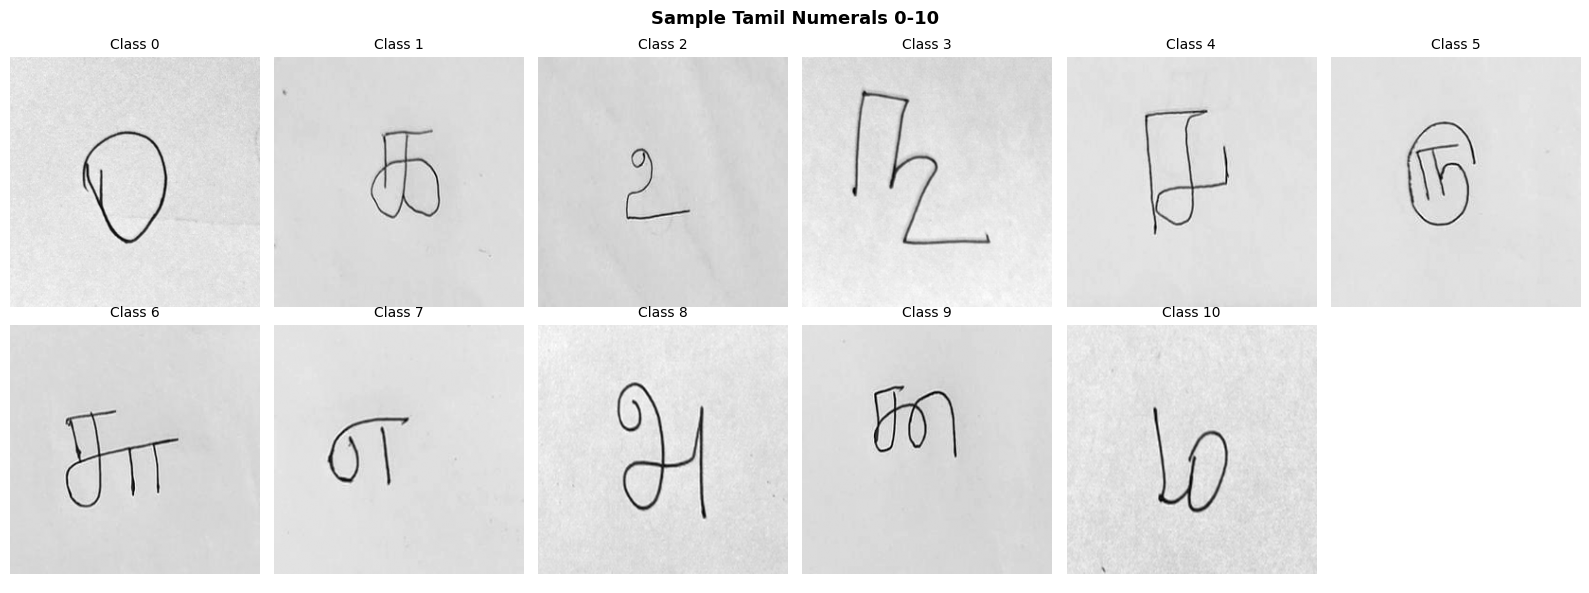

In [9]:
random.seed(SEED)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.flatten()
for label in range(NUM_CLASSES):
    folder = str(label)
    path   = os.path.join(DATA_ROOT, folder)
    if not os.path.isdir(path): continue
    files = [f for f in os.listdir(path)
             if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
    if not files: continue
    img = Image.open(os.path.join(path, random.choice(files))).convert('L')
    axes[label].imshow(img, cmap='gray')
    axes[label].set_title(f'Class {label}', fontsize=10)
    axes[label].axis('off')
axes[NUM_CLASSES].axis('off')
plt.suptitle('Sample Tamil Numerals 0-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 2 — Stage 1: Stroke Descriptor Map (SDM)

SDM shape: (3, 128, 128)  min=0.000  max=1.000


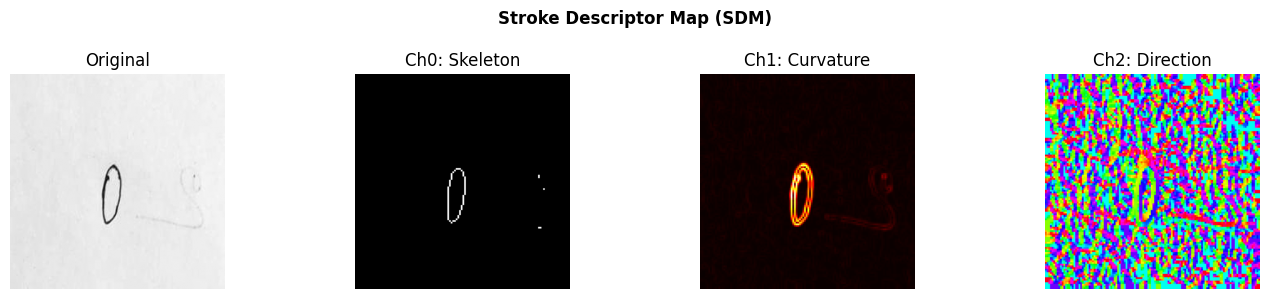

In [10]:
import numpy as np
from PIL import Image
from skimage.morphology import skeletonize
from skimage.filters import sobel_h, sobel_v

def compute_sdm(pil_img, size=64):
    """
    Returns (3, size, size) float32:
      Ch0: skeleton (stroke structure)
      Ch1: curvature proxy (gradient magnitude)
      Ch2: direction field (normalised atan2)
    """
    img_gray = pil_img.convert('L').resize((size, size), Image.BILINEAR)
    arr      = np.array(img_gray, dtype=np.float32) / 255.0
    inv      = 1.0 - arr
    binary   = (inv > 0.3).astype(np.uint8)
    skel     = skeletonize(binary).astype(np.float32)
    gx       = sobel_h(arr)
    gy       = sobel_v(arr)
    mag      = np.sqrt(gx**2 + gy**2)
    mag      = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
    direction = np.arctan2(gy, gx)
    direction = (direction + np.pi) / (2 * np.pi)
    return np.stack([skel, mag, direction], axis=0).astype(np.float32)

# Quick test
folder0 = os.path.join(DATA_ROOT, '0')
files0  = [f for f in os.listdir(folder0)
           if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
sample_pil = Image.open(os.path.join(folder0, files0[0]))
sdm_test   = compute_sdm(sample_pil, IMG_SIZE)
print(f'SDM shape: {sdm_test.shape}  min={sdm_test.min():.3f}  max={sdm_test.max():.3f}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(sample_pil.convert('L'), cmap='gray');  axes[0].set_title('Original')
axes[1].imshow(sdm_test[0], cmap='gray');              axes[1].set_title('Ch0: Skeleton')
axes[2].imshow(sdm_test[1], cmap='hot');               axes[2].set_title('Ch1: Curvature')
axes[3].imshow(sdm_test[2], cmap='hsv');               axes[3].set_title('Ch2: Direction')
for ax in axes: ax.axis('off')
plt.suptitle('Stroke Descriptor Map (SDM)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sdm_channels.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3 — Dataset & DataLoaders

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

class TamilNumeralDataset(Dataset):
    def __init__(self, data_root, class_folders, img_size=64, augment=False):
        self.img_size = img_size
        self.samples  = []
        for folder, label in class_folders.items():
            path = os.path.join(data_root, folder)
            if not os.path.isdir(path): continue
            for fname in os.listdir(path):
                if fname.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
                    self.samples.append((os.path.join(path, fname), label))

        aug = ([transforms.RandomRotation(15),
                transforms.RandomAffine(0, translate=(0.1,0.1),
                                        scale=(0.85,1.15), shear=8)]
               if augment else [])
        self.transform = transforms.Compose([
            transforms.Grayscale(1),
            transforms.Resize((img_size, img_size)),
            *aug,
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        pil_img      = Image.open(fpath).convert('RGB')
        img_t        = self.transform(pil_img)
        sdm_t        = torch.from_numpy(compute_sdm(pil_img, self.img_size))
        return img_t, sdm_t, label

random.seed(SEED)
full_ds = TamilNumeralDataset(DATA_ROOT, CLASS_FOLDERS, IMG_SIZE, augment=False)
N       = len(full_ds)
idx     = list(range(N)); random.shuffle(idx)
n_train = int(0.70 * N); n_val = int(0.15 * N)

val_ds   = Subset(full_ds, idx[n_train:n_train+n_val])
test_ds  = Subset(full_ds, idx[n_train+n_val:])
train_aug = TamilNumeralDataset(DATA_ROOT, CLASS_FOLDERS, IMG_SIZE, augment=True)
train_ds  = Subset(train_aug, idx[:n_train])

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Total={N}  Train={len(train_ds)}  Val={len(val_ds)}  Test={len(test_ds)}')
img_b, sdm_b, lbl_b = next(iter(train_loader))
print(f'img batch: {img_b.shape}  sdm batch: {sdm_b.shape}')

Total=550  Train=385  Val=82  Test=83
img batch: torch.Size([32, 1, 128, 128])  sdm batch: torch.Size([32, 3, 128, 128])


## Step 4 — DSHTT Model Architecture

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from einops import rearrange

# ---- Stage 2A: Tiny CNN Branch ----
class DWSepConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch,  3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()
    def forward(self, x): return self.act(self.bn(self.pw(self.dw(x))))

class TinyCNNBranch(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.GELU(),
            DWSepConv(32,  64, stride=2),
            DWSepConv(64,  96, stride=2),
            DWSepConv(96, embed_dim, stride=2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x): return self.pool(self.layers(x)).flatten(1)

# ---- Stage 2B: Patch Token Encoder ----
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.out = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)
        q = F.elu(q) + 1;  k = F.elu(k) + 1
        kv   = torch.einsum('bhnd,bhnm->bhdm', k, v)
        out  = torch.einsum('bhnd,bhdm->bhnm', q, kv)
        norm = torch.einsum('bhnd,bhd->bhn', q, k.sum(2)).unsqueeze(-1) + 1e-6
        out  = rearrange(out / norm, 'b h n d -> b n (h d)')
        return self.out(out)

class TBlock(nn.Module):
    def __init__(self, dim, heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim); self.attn = LinearAttention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim,hid), nn.GELU(), nn.Dropout(dropout),
                                  nn.Linear(hid,dim), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class PatchTokenEncoder(nn.Module):
    def __init__(self, img_size=64, patch_size=8, embed_dim=128, depth=2, heads=4):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size
        self.patch_emb = nn.Linear(patch_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_emb   = nn.Parameter(torch.randn(1, n_patches+1, embed_dim))
        self.blocks    = nn.ModuleList([TBlock(embed_dim, heads) for _ in range(depth)])
        self.norm      = nn.LayerNorm(embed_dim)
        self.p         = patch_size
    def forward(self, x):
        B = x.shape[0]; p = self.p
        patches = rearrange(x, 'b c (nh p1) (nw p2) -> b (nh nw) (p1 p2 c)', p1=p, p2=p)
        tokens  = self.patch_emb(patches)
        cls     = self.cls_token.expand(B, -1, -1)
        tokens  = torch.cat([cls, tokens], 1) + self.pos_emb
        for blk in self.blocks: tokens = blk(tokens)
        return self.norm(tokens)[:, 0]

# ---- SDM Encoder ----
class SDMEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.GELU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(32, embed_dim, 3, stride=2, padding=1), nn.GELU(),
            nn.AdaptiveAvgPool2d(1))
    def forward(self, sdm): return self.net(sdm).flatten(1)

# ---- Stage 3: SDGU ----
class SDGU(nn.Module):
    """Stroke-Guided Dynamic Gating Unit — Core Novelty"""
    def __init__(self, embed_dim=128):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(embed_dim*3, 256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 2))
        self.proj = nn.Linear(embed_dim, embed_dim)
    def forward(self, cnn_f, tok_f, sdm_f):
        gates = F.softmax(self.gate_net(torch.cat([cnn_f, tok_f, sdm_f], -1)), -1)
        alpha = gates[:, 0:1];  beta = gates[:, 1:2]
        fused = alpha * cnn_f + beta * tok_f + 0.1 * sdm_f
        return self.proj(fused), gates

# ---- Stage 4: Prototype Head ----
class PrototypeHead(nn.Module):
    def __init__(self, embed_dim=128, num_classes=11, temperature=10.0):
        super().__init__()
        self.prototypes  = nn.Parameter(torch.randn(num_classes, embed_dim))
        self.temperature = temperature
    def forward(self, x):
        xn = F.normalize(x, dim=-1)
        pn = F.normalize(self.prototypes, dim=-1)
        return self.temperature * xn @ pn.T

# ---- Full DSHTT ----
class DSHTT(nn.Module):
    def __init__(self, img_size=64, patch_size=8, embed_dim=128,
                 attn_layers=2, num_heads=4, num_classes=11):
        super().__init__()
        self.cnn_branch   = TinyCNNBranch(embed_dim)
        self.token_branch = PatchTokenEncoder(img_size, patch_size, embed_dim, attn_layers, num_heads)
        self.sdm_encoder  = SDMEncoder(embed_dim)
        self.sdgu         = SDGU(embed_dim)
        self.head         = PrototypeHead(embed_dim, num_classes)
    def forward(self, img, sdm):
        cnn_f = self.cnn_branch(img)
        tok_f = self.token_branch(img)
        sdm_f = self.sdm_encoder(sdm)
        fused, gates = self.sdgu(cnn_f, tok_f, sdm_f)
        return self.head(fused), gates

device = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
model = DSHTT(IMG_SIZE, PATCH_SIZE, EMBED_DIM, ATTN_LAYERS, NUM_HEADS, NUM_CLASSES).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'Total params: {total:,}')

with torch.no_grad():
    di = torch.randn(4,1,IMG_SIZE,IMG_SIZE).to(device)
    ds = torch.randn(4,3,IMG_SIZE,IMG_SIZE).to(device)
    lo, ga = model(di, ds)
print(f'Logits: {lo.shape}   Gates: {ga.shape}')

Device: cuda
Total params: 488,002
Logits: torch.Size([4, 11])   Gates: torch.Size([4, 2])


## Step 5 — Training

In [31]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def accuracy(logits, labels):
    return (logits.argmax(1) == labels).float().mean().item()

def run_epoch(loader, train=True):
    model.train(train)
    t_loss = t_acc = 0.0
    alphas, betas = [], []
    with torch.set_grad_enabled(train):
        for img, sdm, lbl in loader:
            img = img.to(device, non_blocking=True)
            sdm = sdm.to(device, non_blocking=True)
            lbl = lbl.to(device, non_blocking=True)
            logits, gates = model(img, sdm)
            loss = criterion(logits, lbl)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            t_loss += loss.item(); t_acc += accuracy(logits, lbl)
            alphas.append(gates[:,0].mean().item())
            betas.append(gates[:,1].mean().item())
    n = len(loader)
    return t_loss/n, t_acc/n, np.mean(alphas), np.mean(betas)

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
           'alpha_mean':[], 'beta_mean':[]}
best_val_acc = 0.0
total_params = sum(p.numel() for p in model.parameters())
t0 = time.time()

for ep in range(1, EPOCHS+1):
    tl,ta,talpha,tbeta = run_epoch(train_loader, True)
    vl,va,valpha,vbeta = run_epoch(val_loader,   False)
    scheduler.step()
    for k,v in zip(['train_loss','val_loss','train_acc','val_acc','alpha_mean','beta_mean'],
                   [tl,vl,ta,va,talpha,tbeta]):
        history[k].append(v)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), 'dshtt_best.pt')
    if ep % 5 == 0 or ep == 1:
        print(f'Ep {ep:3d}/{EPOCHS} | Train {ta*100:.1f}% loss {tl:.4f} | '
              f'Val {va*100:.1f}% loss {vl:.4f} | '
              f'alpha={talpha:.3f} beta={tbeta:.3f} | {time.time()-t0:.0f}s')

print(f'Training done. Best val acc: {best_val_acc*100:.2f}%')

Ep   1/300 | Train 57.9% loss 1.6060 | Val 48.7% loss 1.5747 | alpha=0.990 beta=0.010 | 4s
Ep   5/300 | Train 63.0% loss 1.4246 | Val 41.7% loss 1.7125 | alpha=0.988 beta=0.012 | 21s
Ep  10/300 | Train 54.8% loss 1.5164 | Val 44.0% loss 1.7486 | alpha=0.985 beta=0.015 | 43s
Ep  15/300 | Train 52.6% loss 1.5770 | Val 62.3% loss 1.4305 | alpha=0.990 beta=0.010 | 65s
Ep  20/300 | Train 64.2% loss 1.3987 | Val 47.9% loss 1.5499 | alpha=0.993 beta=0.007 | 87s
Ep  25/300 | Train 58.4% loss 1.4404 | Val 53.1% loss 1.5245 | alpha=0.994 beta=0.006 | 109s
Ep  30/300 | Train 66.6% loss 1.3555 | Val 60.0% loss 1.4461 | alpha=0.990 beta=0.010 | 130s
Ep  35/300 | Train 60.1% loss 1.4813 | Val 47.7% loss 1.6754 | alpha=0.993 beta=0.007 | 151s
Ep  40/300 | Train 54.1% loss 1.5215 | Val 44.4% loss 1.6748 | alpha=0.993 beta=0.007 | 173s
Ep  45/300 | Train 60.1% loss 1.5221 | Val 77.5% loss 1.2802 | alpha=0.992 beta=0.008 | 196s
Ep  50/300 | Train 63.5% loss 1.3358 | Val 55.0% loss 1.3743 | alpha=0.994 b

## Step 6 — Training Curves

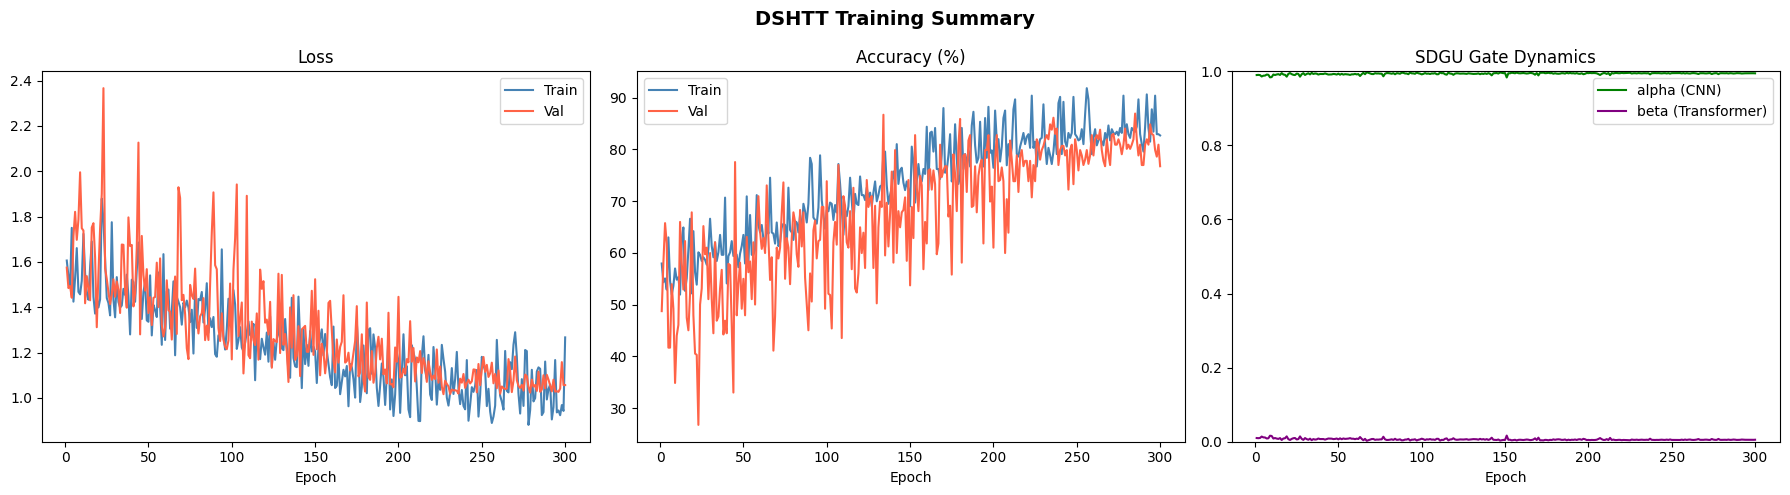

In [32]:
ep_range = range(1, EPOCHS+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ep_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep_range, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep_range, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot(ep_range, [a*100 for a in history['val_acc']],   label='Val',   color='tomato')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(ep_range, history['alpha_mean'], label='alpha (CNN)',         color='green')
axes[2].plot(ep_range, history['beta_mean'],  label='beta (Transformer)',  color='purple')
axes[2].set_title('SDGU Gate Dynamics'); axes[2].legend()
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1)

plt.suptitle('DSHTT Training Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Test Set Evaluation

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load('dshtt_best.pt', map_location=device))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for img, sdm, lbl in test_loader:
        logits, _ = model(img.to(device), sdm.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(lbl.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(classification_report(all_labels, all_preds,
      target_names=[f'Class {i}' for i in range(NUM_CLASSES)]))

Test Accuracy: 74.70%
              precision    recall  f1-score   support

     Class 0       0.89      0.80      0.84        10
     Class 1       0.83      0.71      0.77         7
     Class 2       0.78      0.78      0.78         9
     Class 3       0.60      0.67      0.63         9
     Class 4       0.40      0.29      0.33         7
     Class 5       0.75      1.00      0.86         6
     Class 6       0.75      0.60      0.67        10
     Class 7       0.75      1.00      0.86         6
     Class 8       1.00      1.00      1.00         7
     Class 9       0.60      0.50      0.55         6
    Class 10       0.75      1.00      0.86         6

    accuracy                           0.75        83
   macro avg       0.74      0.76      0.74        83
weighted avg       0.74      0.75      0.74        83



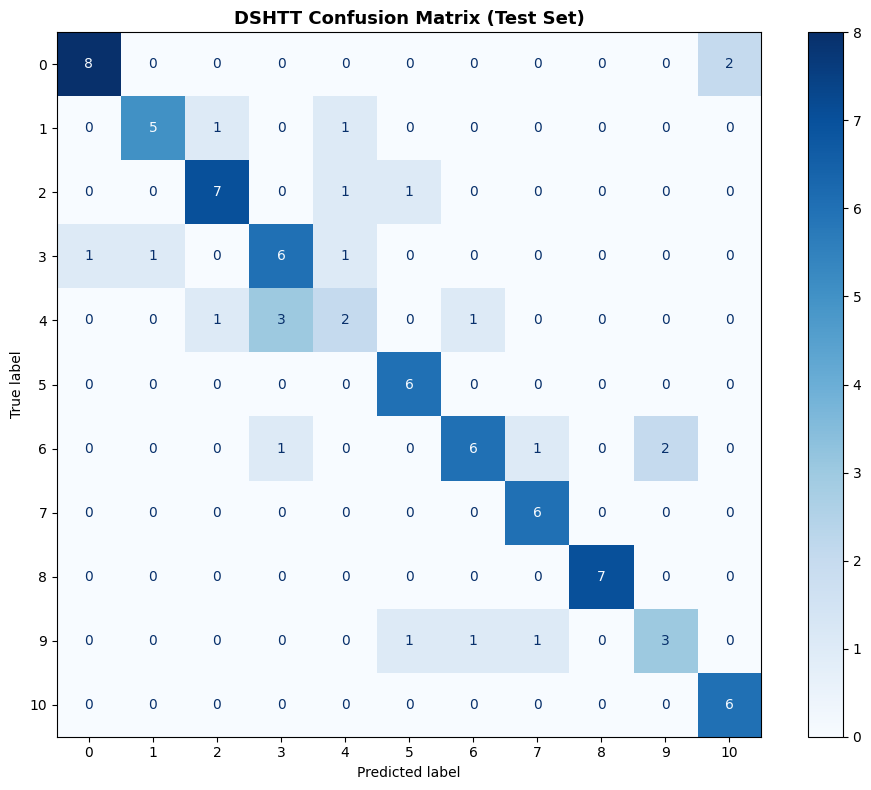

In [34]:
cm   = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=[str(i) for i in range(NUM_CLASSES)]).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('DSHTT Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — SDGU Gate Analysis

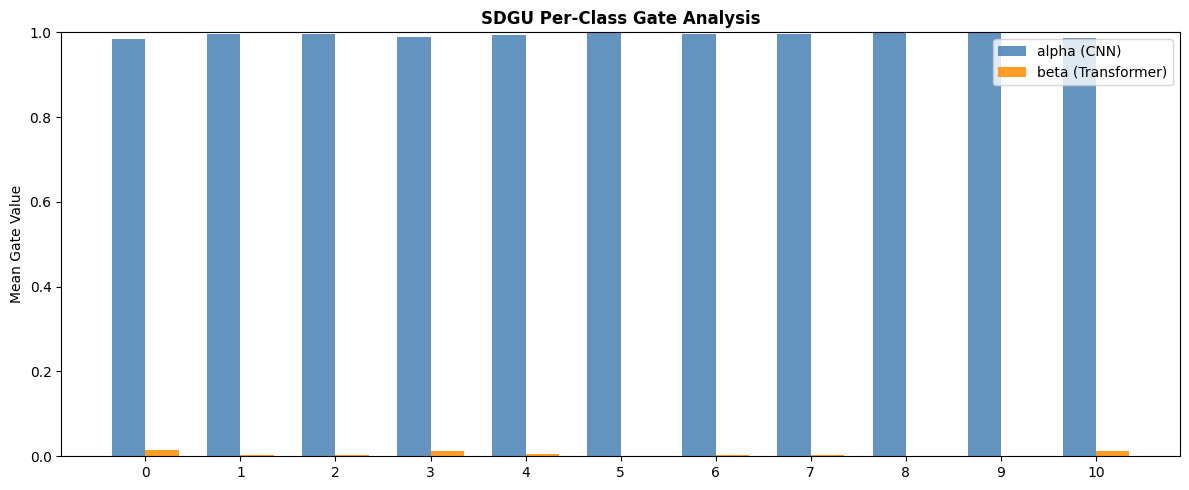

In [35]:
model.eval()
cls_alpha = {i:[] for i in range(NUM_CLASSES)}
cls_beta  = {i:[] for i in range(NUM_CLASSES)}

with torch.no_grad():
    for img, sdm, lbl in test_loader:
        _, gates = model(img.to(device), sdm.to(device))
        g = gates.cpu().numpy()
        for i, l in enumerate(lbl.numpy()):
            cls_alpha[l].append(g[i,0]); cls_beta[l].append(g[i,1])

ma = [np.mean(cls_alpha[c]) for c in range(NUM_CLASSES)]
mb = [np.mean(cls_beta[c])  for c in range(NUM_CLASSES)]
x  = np.arange(NUM_CLASSES); w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-w/2, ma, w, label='alpha (CNN)',         color='steelblue',  alpha=0.85)
ax.bar(x+w/2, mb, w, label='beta (Transformer)',  color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'{i}' for i in range(NUM_CLASSES)])
ax.set_ylabel('Mean Gate Value'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('SDGU Per-Class Gate Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Prototype Space (t-SNE)

Running t-SNE...


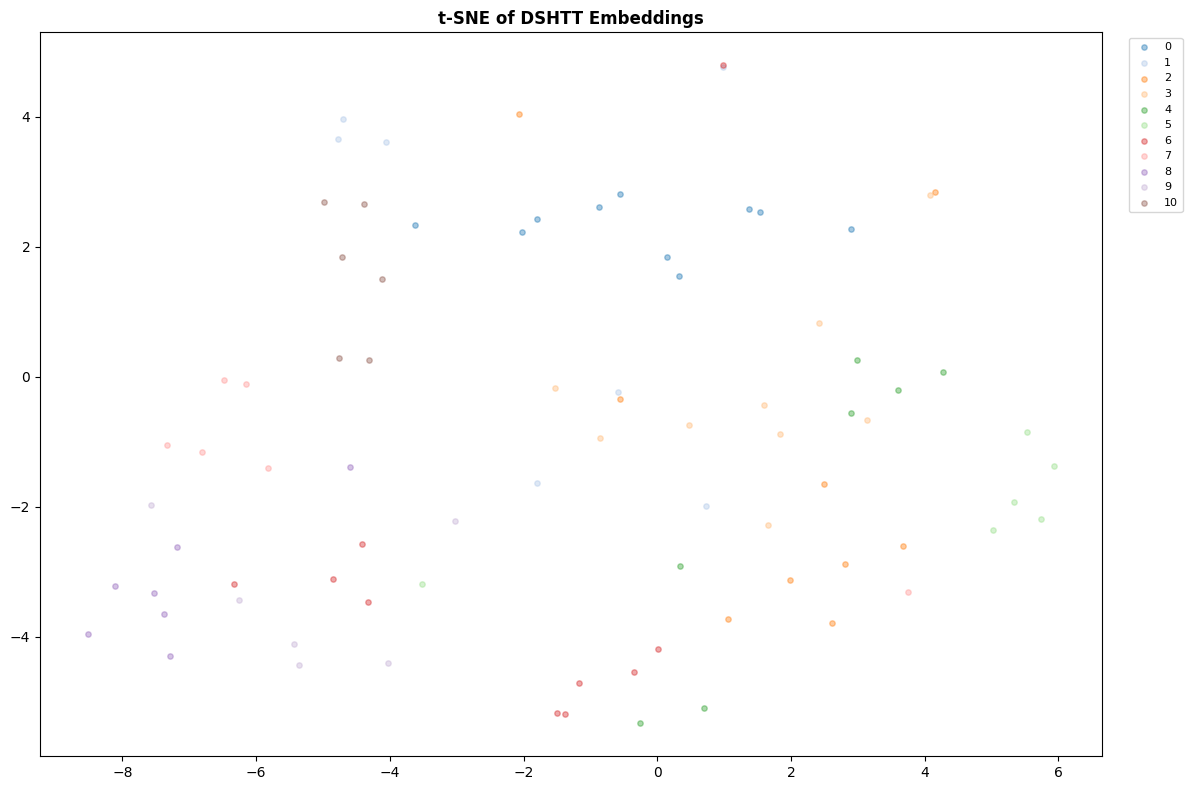

In [36]:
from sklearn.manifold import TSNE
import seaborn as sns

model.eval()
embeds, elabels = [], []
with torch.no_grad():
    for img, sdm, lbl in test_loader:
        img = img.to(device); sdm = sdm.to(device)
        cf  = model.cnn_branch(img)
        tf  = model.token_branch(img)
        sf  = model.sdm_encoder(sdm)
        fu, _ = model.sdgu(cf, tf, sf)
        embeds.append(F.normalize(fu, dim=-1).cpu().numpy())
        elabels.extend(lbl.numpy())

embeds = np.concatenate(embeds)
print('Running t-SNE...')
proj = proj = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000).fit_transform(embeds)

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette('tab20', NUM_CLASSES)
for c in range(NUM_CLASSES):
    mask = np.array(elabels) == c
    ax.scatter(proj[mask,0], proj[mask,1], color=palette[c], alpha=0.4, s=15, label=f'{c}')
ax.set_title('t-SNE of DSHTT Embeddings', fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Save to Drive

In [15]:
import shutil, json

SAVE_DIR = '/content/drive/MyDrive/DSHTT_Results'
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy('dshtt_best.pt', os.path.join(SAVE_DIR, 'dshtt_best.pt'))
for f in ['training_curves.png','confusion_matrix.png','gate_analysis.png',
          'tsne_embeddings.png','sample_images.png','sdm_channels.png']:
    if os.path.exists(f): shutil.copy(f, os.path.join(SAVE_DIR, f))

results = {
    'test_accuracy': float(test_acc), 'best_val_acc': float(best_val_acc),
    'total_params': total_params,
    'config': dict(IMG_SIZE=IMG_SIZE, PATCH_SIZE=PATCH_SIZE, EMBED_DIM=EMBED_DIM,
                   ATTN_LAYERS=ATTN_LAYERS, NUM_HEADS=NUM_HEADS,
                   EPOCHS=EPOCHS, BATCH_SIZE=BATCH_SIZE, LR=LR),
    'history': {k: [float(v) for v in vs] for k, vs in history.items()}
}
with open(os.path.join(SAVE_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f'Saved to {SAVE_DIR}')
print(f'Best Val Acc : {best_val_acc*100:.2f}%')
print(f'Test Acc     : {test_acc*100:.2f}%')
print(f'Params       : {total_params:,}')

Saved to /content/drive/MyDrive/DSHTT_Results
Best Val Acc : 27.78%
Test Acc     : 22.89%
Params       : 463,426


## Step 11 — Single Image Inference Demo

True class: 1  |  File: AISelect_20260312_213247_Samsung Notes.png


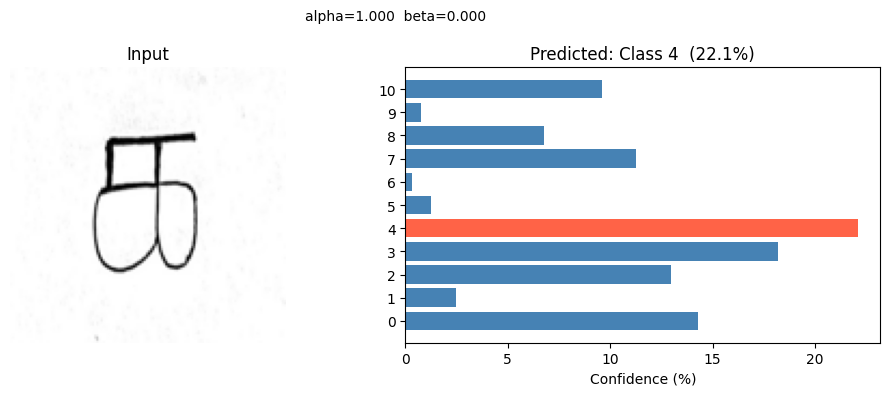

Predicted: 4  Confidence: 22.1%


In [60]:
def predict_single(image_path):
    model.eval()
    pil_img = Image.open(image_path).convert('RGB')
    tf = transforms.Compose([transforms.Grayscale(1),
                              transforms.Resize((IMG_SIZE, IMG_SIZE)),
                              transforms.ToTensor(),
                              transforms.Normalize([0.5],[0.5])])
    img_t = tf(pil_img).unsqueeze(0).to(device)
    sdm_t = torch.from_numpy(compute_sdm(pil_img, IMG_SIZE)).unsqueeze(0).to(device)
    with torch.no_grad():
        logits, gates = model(img_t, sdm_t)
        probs = F.softmax(logits, -1).squeeze(0).cpu().numpy()
    pred = int(probs.argmax()); conf = float(probs[pred])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(pil_img.convert('L').resize((IMG_SIZE,IMG_SIZE)), cmap='gray')
    axes[0].set_title('Input'); axes[0].axis('off')
    colors = ['tomato' if i==pred else 'steelblue' for i in range(NUM_CLASSES)]
    axes[1].barh(range(NUM_CLASSES), probs*100, color=colors)
    axes[1].set_yticks(range(NUM_CLASSES))
    axes[1].set_yticklabels([str(i) for i in range(NUM_CLASSES)])
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Predicted: Class {pred}  ({conf*100:.1f}%)')
    plt.suptitle(f'alpha={gates[0,0]:.3f}  beta={gates[0,1]:.3f}', fontsize=10)
    plt.tight_layout(); plt.show()
    return pred, conf

# Demo on a random image
c = random.randint(0, NUM_CLASSES-1)
d = os.path.join(DATA_ROOT, str(c))
fs = [f for f in os.listdir(d) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
fp = os.path.join(d, random.choice(fs))
print(f'True class: {c}  |  File: {os.path.basename(fp)}')
pred, conf = predict_single(fp)
print(f'Predicted: {pred}  Confidence: {conf*100:.1f}%')